# 03 - Exploratory Data Analysis (EDA)

**Purpose**: Analyze the cleaned data to find patterns, trends, and business insights.


## Step 1: Import Libraries

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)

# Set plot style
plt.style.use('default')
sns.set_palette("husl")

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load Cleaned Dataset

In [2]:
# Load the cleaned dataset
df = pd.read_csv('cleaned_data.csv')

print(f"Dataset loaded. Shape: {df.shape}")
print("\n")
print("First few rows:")
df.head()

Dataset loaded. Shape: (100000, 25)


First few rows:


,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,Order_Time,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19,Male,Hyderabad,Central,RES936,Restaurant_29,Chinese,10/20/2024,0:00,187.0,15.75,NaN,NaN,NaN,UPI,Delivered,NaN,DP563,5,4.4,Weekend,True,0.13
1,ORD000002,CUST6515,39,Female,Chennai,North,RES689,Restaurant_419,Chinese,8/12/2024,0:00,20.0,29.50,4869.0,20.0,4849.0,COD,Delivered,NaN,DP369,5,4.7,Weekday,True,0.48
2,ORD000003,CUST1765,39,Male,Delhi,South,RES723,Restaurant_244,Arabian,12/8/2024,0:00,207.0,9.97,757.0,20.0,737.0,Wallet,Delivered,NaN,DP580,4,4.9,Weekend,True,0.08
3,ORD000004,CUST2744,39,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,10/8/2024,0:00,143.0,15.68,0.0,0.0,0.0,UPI,Cancelled,Late Delivery,DP155,0,3.4,Weekday,True,0.04
4,ORD000005,CUST4389,57,Female,Chennai,South,RES419,Restaurant_262,Chinese,2/4/2024,0:00,51.0,9.60,372.0,20.0,352.0,Card,Delivered,NaN,DP728,2,4.4,Weekend,False,0.12


---
# Part 1: Customer & Order Analysis
---

## Analysis 1: Identify Top-Spending Customers

In [3]:
# Group by customer and calculate total spending
customer_spending = df.groupby('Customer_ID')['Final_Amount'].sum().reset_index()

# Sort by spending
customer_spending = customer_spending.sort_values('Final_Amount', ascending=False)

# Get top 10 customers
top_10_customers = customer_spending.head(10)

print("Top 10 Spending Customers:")
print("\n")
print(top_10_customers)
print("\n")

Top 10 Spending Customers:


     Customer_ID  Final_Amount
4266    CUST5267   49474.26640
606     CUST1606   46656.36220
5705    CUST6706   44078.69880
5292    CUST6293   42912.57330
5456    CUST6457   41094.81776
258     CUST1258   39941.00000
6590    CUST7591   39625.89820
7523    CUST8524   39584.44240
5251    CUST6252   39098.79320
7818    CUST8819   39023.29680




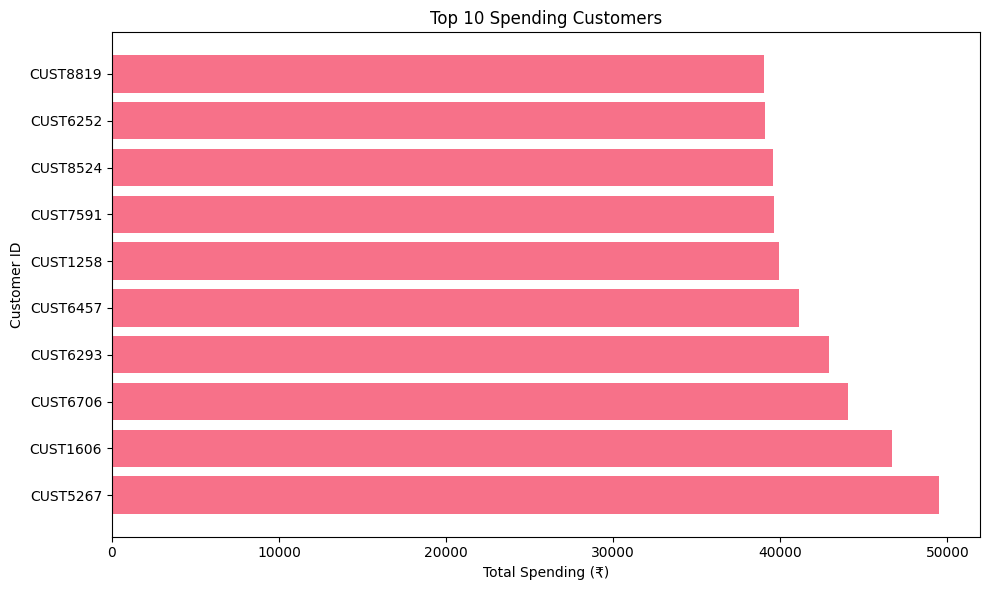

In [4]:
# Visualize top 10 customers
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_10_customers)), top_10_customers['Final_Amount'])
plt.yticks(range(len(top_10_customers)), top_10_customers['Customer_ID'])
plt.xlabel('Total Spending (₹)')
plt.ylabel('Customer ID')
plt.title('Top 10 Spending Customers')
plt.tight_layout()
plt.show()

- **Observation:** A small group of customers contributes a significantly higher share of total spending compared to others.  

- **Possible Reason:** This pattern may be driven by repeat purchases, loyal customers, or customers placing high-value orders frequently.  

- **Business Recommendation:** Implement loyalty programs, personalized discounts, and targeted marketing strategies to retain high-value customers and increase customer lifetime value.

## Analysis 2: Age Group vs Order Value


In [5]:
# Create age groups
# Using simple bins for age ranges
bins = [18, 25, 35, 45, 55, 80]
labels = ['18-25', '26-35', '36-45', '46-55', '56+']

df['Age_Group'] = pd.cut(df['Customer_Age'], bins=bins, labels=labels)

# Calculate average order value by age group
age_spending = df.groupby('Age_Group')['Final_Amount'].agg(['mean', 'count']).reset_index()
age_spending.columns = ['Age_Group', 'Avg_Order_Value', 'Order_Count']

print("Age Group Analysis:")
print("\n")
print(age_spending)
print("\n")

Age Group Analysis:


  Age_Group  Avg_Order_Value  Order_Count
0     18-25      1840.514536         5819
1     26-35      1883.432515         8395
2     36-45      1852.846073        44141
3     46-55      1867.204873         8437
4       56+      1807.863379         4067




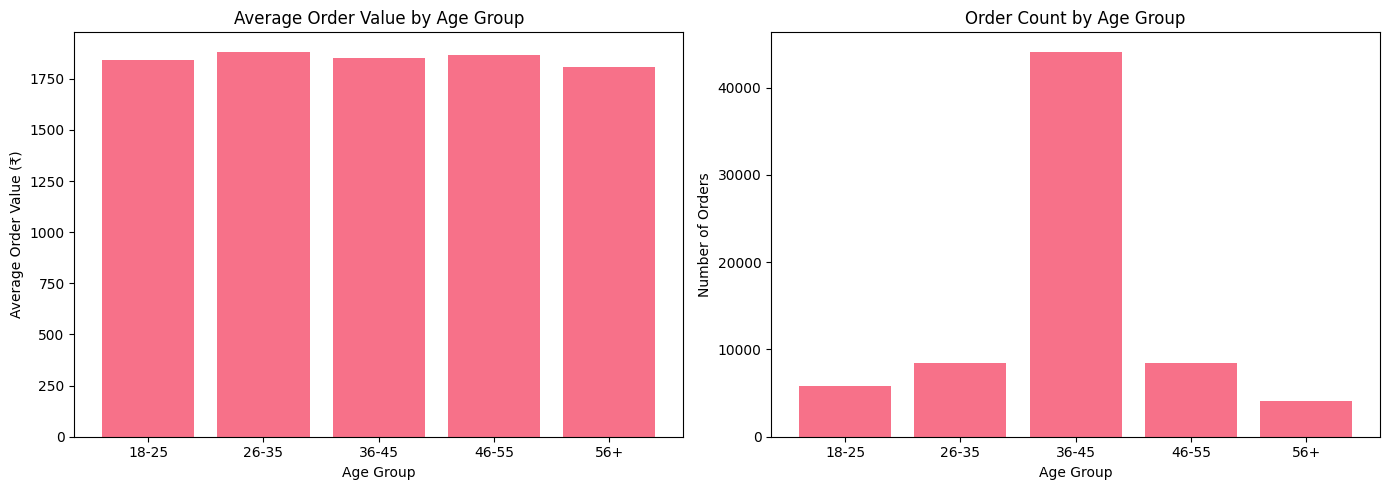

In [6]:
# Visualize age group spending
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Average order value by age group
ax1.bar(age_spending['Age_Group'], age_spending['Avg_Order_Value'])
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Average Order Value (₹)')
ax1.set_title('Average Order Value by Age Group')

# Plot 2: Number of orders by age group
ax2.bar(age_spending['Age_Group'], age_spending['Order_Count'])
ax2.set_xlabel('Age Group')
ax2.set_ylabel('Number of Orders')
ax2.set_title('Order Count by Age Group')

plt.tight_layout()
plt.show()

- **Observation:** The 36–45 age group has the highest order count, while the average order value remains relatively similar across all age groups.  

- **Possible Reason:** Middle-aged customers may purchase more frequently due to stable income levels, family needs, or higher dependency on food delivery services.  

- **Business Recommendation:** Focus targeted promotions, subscription plans, and personalized offers on the 36–45 age segment to improve customer retention and overall sales volume.

## Analysis 3: Weekend vs Weekday Order Patterns


In [7]:
# Analyze weekday vs weekend patterns
day_analysis = df.groupby('Order_Day').agg({
    'Order_ID': 'count',
    'Final_Amount': 'mean'
}).reset_index()

day_analysis.columns = ['Day_Type', 'Total_Orders', 'Avg_Order_Value']

print("Weekday vs Weekend Analysis:")
print("\n")
print(day_analysis)
print("\n")

Weekday vs Weekend Analysis:


  Day_Type  Total_Orders  Avg_Order_Value
0  Weekday         71370      1857.561763
1  Weekend         28630      1848.860068




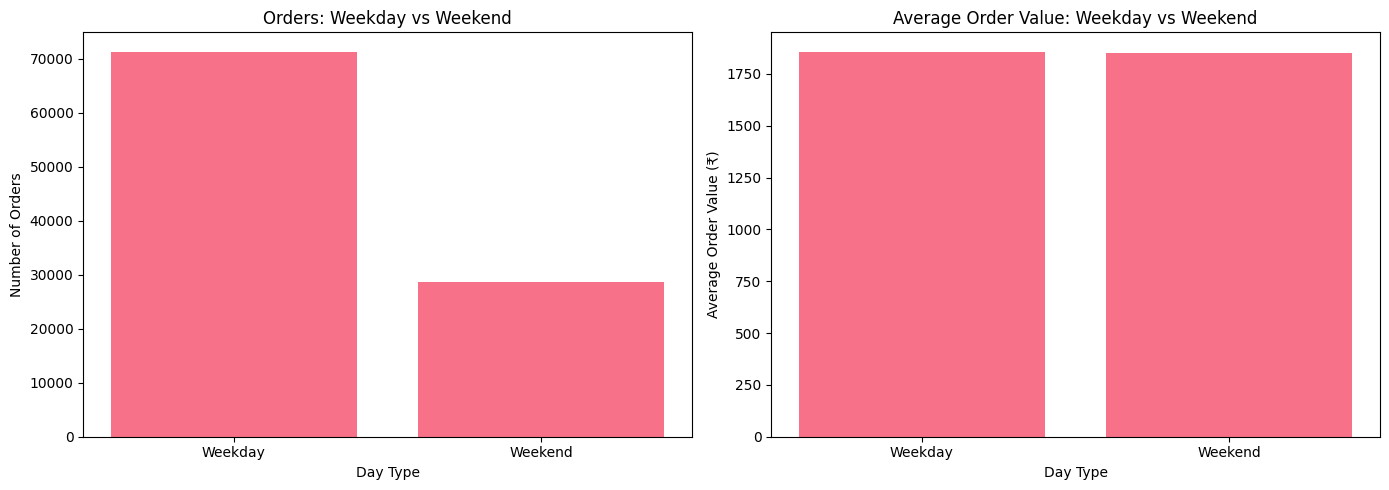

In [8]:
# Visualize weekday vs weekend patterns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Order count
ax1.bar(day_analysis['Day_Type'], day_analysis['Total_Orders'])
ax1.set_xlabel('Day Type')
ax1.set_ylabel('Number of Orders')
ax1.set_title('Orders: Weekday vs Weekend')

# Plot 2: Average order value
ax2.bar(day_analysis['Day_Type'], day_analysis['Avg_Order_Value'])
ax2.set_xlabel('Day Type')
ax2.set_ylabel('Average Order Value (₹)')
ax2.set_title('Average Order Value: Weekday vs Weekend')

plt.tight_layout()
plt.show()

- **Observation:** Weekdays record significantly higher order volumes compared to weekends, while the average order value remains almost identical across both periods.  

- **Possible Reason:** Customers may rely more on food delivery services during working days due to busy schedules and limited time for cooking.  

- **Business Recommendation:** Introduce weekend-specific offers, combo deals, and promotional campaigns to increase weekend order volume and balance demand across the week.

---
# Part 2: Revenue & Profit Analysis
---

## Analysis 4: Monthly Revenue Trends

In [9]:
# Convert Order_Date to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Extract month and year
df['Year_Month'] = df['Order_Date'].dt.to_period('M')

# Calculate monthly revenue
monthly_revenue = df.groupby('Year_Month')['Final_Amount'].sum().reset_index()
monthly_revenue['Year_Month'] = monthly_revenue['Year_Month'].astype(str)

print("Monthly Revenue:")
print("\n")
print(monthly_revenue)
print("\n")

Monthly Revenue:


   Year_Month  Final_Amount
0     2024-01  1.135711e+07
1     2024-02  1.044536e+07
2     2024-03  1.107597e+07
3     2024-04  1.079772e+07
4     2024-05  1.103777e+07
5     2024-06  1.087639e+07
6     2024-07  1.282336e+07
7     2024-08  1.100999e+07
8     2024-09  1.113770e+07
9     2024-10  1.093499e+07
10    2024-11  1.080801e+07
11    2024-12  1.066600e+07




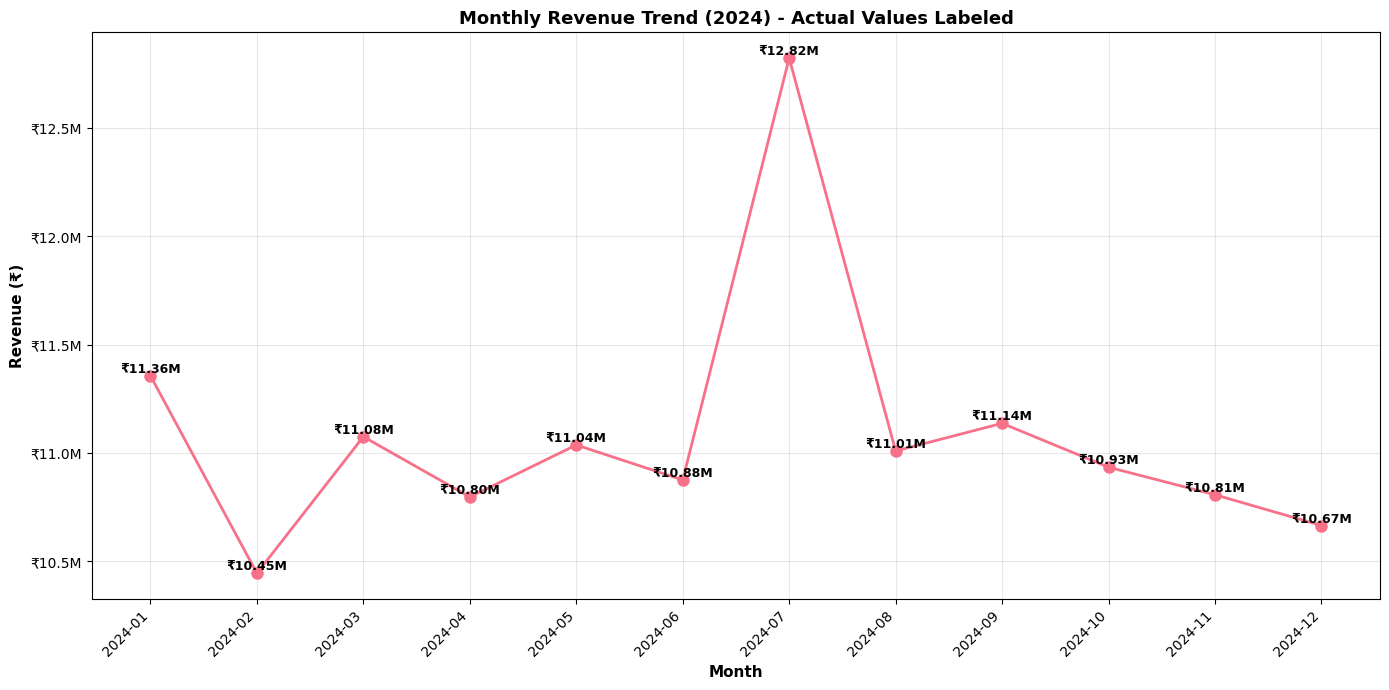


MONTHLY REVENUE DETAILED BREAKDOWN

Month                   Revenue             Change     Change %
--------------------------------------------------------------------------------
2024-01      ₹          11.36M                  —            —
2024-02      ₹          10.45M           ↓ ₹0.91M      ↓ 8.03%
2024-03      ₹          11.08M           ↑ ₹0.63M      ↑ 6.04%
2024-04      ₹          10.80M           ↓ ₹0.28M      ↓ 2.51%
2024-05      ₹          11.04M           ↑ ₹0.24M      ↑ 2.22%
2024-06      ₹          10.88M           ↓ ₹0.16M      ↓ 1.46%
2024-07      ₹          12.82M           ↑ ₹1.95M     ↑ 17.90%
2024-08      ₹          11.01M           ↓ ₹1.81M     ↓ 14.14%
2024-09      ₹          11.14M           ↑ ₹0.13M      ↑ 1.16%
2024-10      ₹          10.93M           ↓ ₹0.20M      ↓ 1.82%
2024-11      ₹          10.81M           ↓ ₹0.13M      ↓ 1.16%
2024-12      ₹          10.67M           ↓ ₹0.14M      ↓ 1.31%
--------------------------------------------------------------

In [10]:
# Visualize monthly revenue trend with value labels
fig, ax = plt.subplots(figsize=(14, 7))

# Plot the line chart
ax.plot(range(len(monthly_revenue)), monthly_revenue['Final_Amount'].values, marker='o', linewidth=2, markersize=8)

# Add value labels on each point
for i, (month, revenue) in enumerate(zip(monthly_revenue['Year_Month'], monthly_revenue['Final_Amount'])):
    ax.text(i, revenue, f'₹{revenue/1e6:.2f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Calculate and display month-over-month change
monthly_revenue['MoM_Change'] = monthly_revenue['Final_Amount'].diff()
monthly_revenue['MoM_Change_Pct'] = (monthly_revenue['MoM_Change'] / monthly_revenue['Final_Amount'].shift(1) * 100).round(2)

ax.set_xlabel('Month', fontsize=11, fontweight='bold')
ax.set_ylabel('Revenue (₹)', fontsize=11, fontweight='bold')
ax.set_title('Monthly Revenue Trend (2024) - Actual Values Labeled', fontsize=13, fontweight='bold')
ax.set_xticks(range(len(monthly_revenue)))
ax.set_xticklabels(monthly_revenue['Year_Month'], rotation=45, ha='right')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

# Print detailed breakdown
print("\n" + "="*80)
print("MONTHLY REVENUE DETAILED BREAKDOWN")
print("="*80)
print(f"\n{'Month':<12} {'Revenue':>18} {'Change':>18} {'Change %':>12}")
print("-"*80)
for idx, row in monthly_revenue.iterrows():
    if idx == 0:
        change_str = "—"
        pct_str = "—"
    else:
        change_val = row['MoM_Change']
        change_sign = "↑" if change_val >= 0 else "↓"
        change_str = f"{change_sign} ₹{abs(change_val)/1e6:.2f}M"
        pct_str = f"{change_sign} {abs(row['MoM_Change_Pct']):.2f}%"
    
    print(f"{row['Year_Month']:<12} ₹{row['Final_Amount']/1e6:>15.2f}M {change_str:>18} {pct_str:>12}")

print("-"*80)
print(f"\nKey Insights:")
print(f"  • Highest Revenue: {monthly_revenue.loc[monthly_revenue['Final_Amount'].idxmax(), 'Year_Month']} (₹{monthly_revenue['Final_Amount'].max()/1e6:.2f}M)")
print(f"  • Lowest Revenue: {monthly_revenue.loc[monthly_revenue['Final_Amount'].idxmin(), 'Year_Month']} (₹{monthly_revenue['Final_Amount'].min()/1e6:.2f}M)")
print(f"  • Difference: ₹{(monthly_revenue['Final_Amount'].max() - monthly_revenue['Final_Amount'].min())/1e6:.2f}M ({((monthly_revenue['Final_Amount'].max() - monthly_revenue['Final_Amount'].min())/monthly_revenue['Final_Amount'].min()*100):.2f}%)")
print(f"  • Average Monthly Revenue: ₹{monthly_revenue['Final_Amount'].mean()/1e6:.2f}M")

- **Observation:** Revenue remained relatively stable throughout the year, with a significant spike observed in July compared to other months.  

- **Possible Reason:** The sudden increase in July revenue may be influenced by seasonal demand, promotional campaigns, festive periods, or potential data anomalies/outliers.  

- **Business Recommendation:** Analyze July transactions in detail to identify the exact drivers behind the spike and replicate successful strategies during low-performing months while validating for data inconsistencies.

## Analysis 5: Impact of Discounts on Profit

**Business Question**: How do discounts affect profit margins?

**Why important**: Discounts attract customers but reduce profit. We need to find the right balance.

In [11]:
# Create discount categories
df['Discount_Category'] = pd.cut(df['Discount_Applied'], 
                                   bins=[-1, 0, 50, 100, 200, 1000],
                                   labels=['No Discount', '1-50', '51-100', '101-200', '200+'])

# Calculate average profit margin by discount category
discount_profit = df.groupby('Discount_Category')['Profit_Margin'].mean().reset_index()

print("Profit Margin by Discount Level:")
print("\n")
print(discount_profit)
print("\n")

Profit Margin by Discount Level:


  Discount_Category  Profit_Margin
0       No Discount       0.151304
1              1-50       0.149025
2            51-100       0.150782
3           101-200       0.154327
4              200+       0.152312




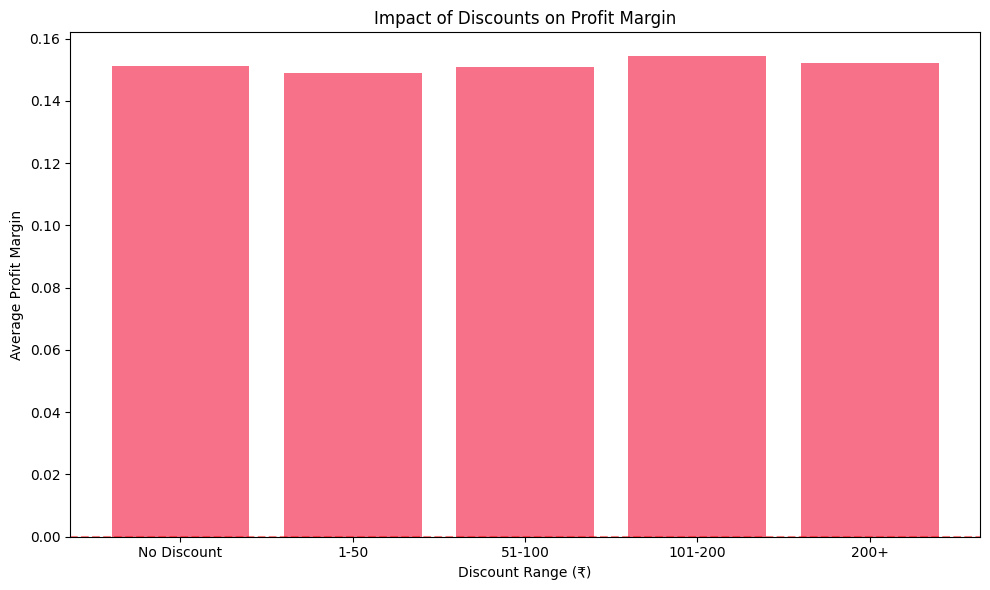

In [12]:
# Visualize discount impact
plt.figure(figsize=(10, 6))
plt.bar(discount_profit['Discount_Category'], discount_profit['Profit_Margin'])
plt.xlabel('Discount Range (₹)')
plt.ylabel('Average Profit Margin')
plt.title('Impact of Discounts on Profit Margin')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

- **Observation:** Profit margins remain relatively stable across all discount ranges, with no major decline observed even at higher discount levels.  

- **Possible Reason:** The business may have optimized pricing strategies or sufficient product margins that help absorb discount impacts without significantly affecting profitability.  

- **Business Recommendation:** Continue using targeted discount strategies while monitoring high-discount campaigns to ensure they contribute to customer acquisition and sales growth without reducing long-term profitability.

## Analysis 6: High-Revenue Cities and Cuisines

**Business Question**: Which cities and cuisines generate the most revenue?

**Why important**: Focus marketing and restaurant partnerships on high-revenue areas.

In [13]:
# Revenue by city
city_revenue = df.groupby('City')['Final_Amount'].sum().reset_index()
city_revenue = city_revenue.sort_values('Final_Amount', ascending=False).head(10)

print("Top 10 Revenue-Generating Cities:")
print("\n")
print(city_revenue)
print("\n")

Top 10 Revenue-Generating Cities:


        City  Final_Amount
3  Hyderabad  4.458536e+07
0  Bangalore  2.253510e+07
1    Chennai  2.199662e+07
2      Delhi  2.199393e+07
4     Mumbai  2.185934e+07




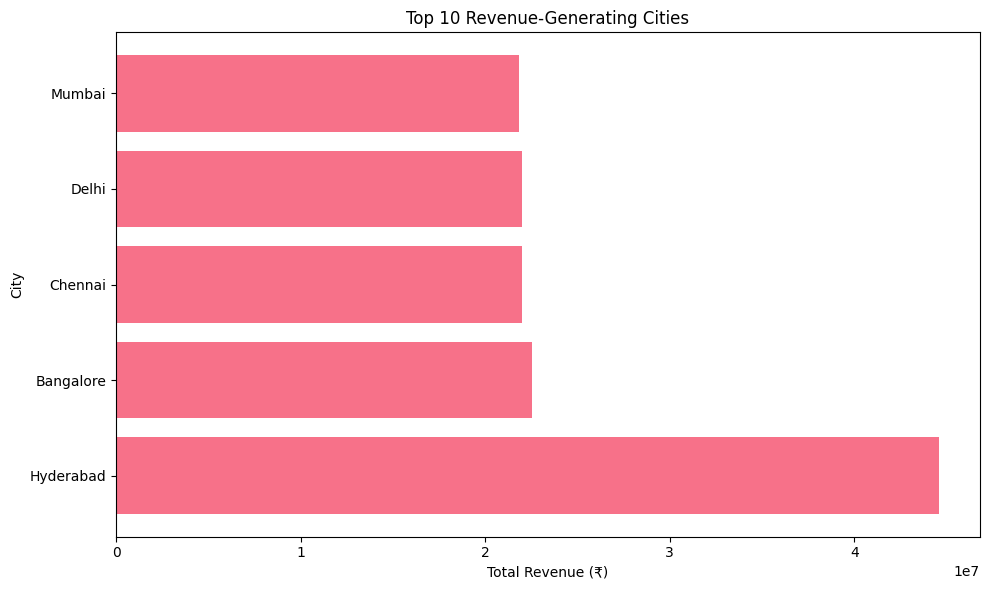

In [14]:
# Visualize city revenue
plt.figure(figsize=(10, 6))
plt.barh(range(len(city_revenue)), city_revenue['Final_Amount'])
plt.yticks(range(len(city_revenue)), city_revenue['City'])
plt.xlabel('Total Revenue (₹)')
plt.ylabel('City')
plt.title('Top 10 Revenue-Generating Cities')
plt.tight_layout()
plt.show()

- **Observation:** Hyderabad generates significantly higher revenue compared to other cities, making it the top-performing market in the dataset.  

- **Possible Reason:** Higher revenue may be driven by a larger customer base, stronger market demand, better customer retention, or increased order frequency in the city.  

- **Business Recommendation:** Expand successful strategies used in Hyderabad to other cities while increasing localized marketing and operational investments in lower-performing regions to improve overall revenue distribution.

In [15]:
# Revenue by cuisine
cuisine_revenue = df.groupby('Cuisine_Type')['Final_Amount'].sum().reset_index()
cuisine_revenue = cuisine_revenue.sort_values('Final_Amount', ascending=False).head(10)

print("Top 10 Revenue-Generating Cuisines:")
print("\n")
print(cuisine_revenue)
print("\n")

Top 10 Revenue-Generating Cuisines:


  Cuisine_Type  Final_Amount
2       Indian  2.714629e+07
4      Mexican  2.700087e+07
1      Chinese  2.654096e+07
0      Arabian  2.644586e+07
3      Italian  2.583638e+07




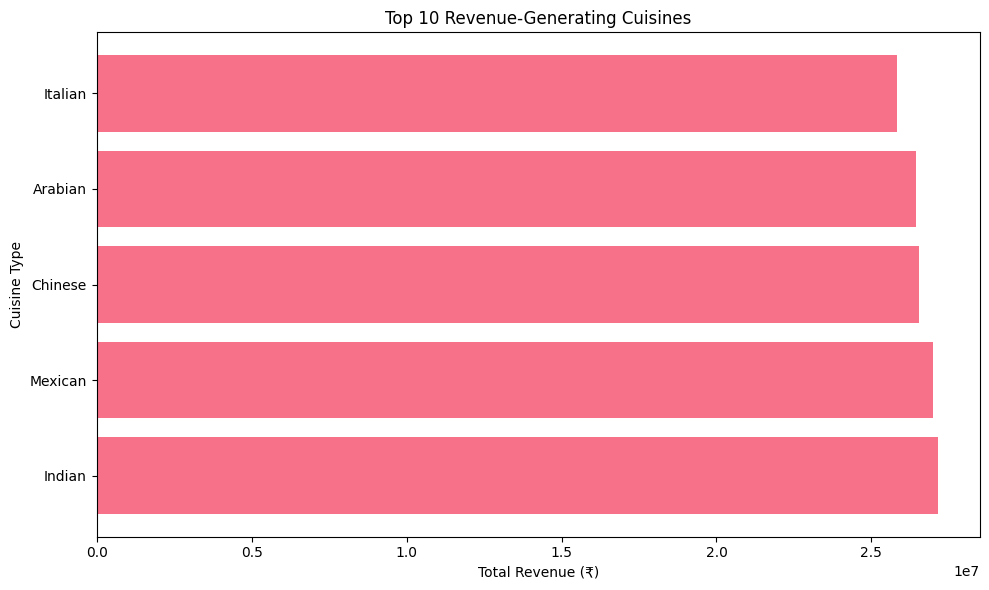

In [16]:
# Visualize cuisine revenue
plt.figure(figsize=(10, 6))
plt.barh(range(len(cuisine_revenue)), cuisine_revenue['Final_Amount'])
plt.yticks(range(len(cuisine_revenue)), cuisine_revenue['Cuisine_Type'])
plt.xlabel('Total Revenue (₹)')
plt.ylabel('Cuisine Type')
plt.title('Top 10 Revenue-Generating Cuisines')
plt.tight_layout()
plt.show()

- **Observation:** Indian cuisine generates the highest revenue among all cuisine categories, while other cuisines show relatively similar revenue performance.  

- **Possible Reason:** Higher revenue from Indian cuisine may be influenced by stronger local preference, wider customer reach, and frequent repeat orders.  

- **Business Recommendation:** Focus on expanding popular Indian cuisine offerings while promoting underperforming cuisines through combo deals, targeted campaigns, and personalized recommendations to diversify revenue sources.

---
# Part 3: Delivery Performance Analysis
---

## Analysis 7: Average Delivery Time by City

**Business Question**: Which cities have the fastest/slowest deliveries?

**Why important**: Fast delivery improves customer satisfaction. Slow cities need improvement.

In [17]:
# Calculate average delivery time by city
city_delivery = df.groupby('City')['Delivery_Time_Min'].mean().reset_index()
city_delivery = city_delivery.sort_values('Delivery_Time_Min', ascending=False).head(10)

print("Average Delivery Time by City (Top 10 Slowest):")
print("\n")
print(city_delivery)
print("\n")

Average Delivery Time by City (Top 10 Slowest):


        City  Delivery_Time_Min
4     Mumbai         125.937246
3  Hyderabad         125.070872
2      Delhi         124.896376
1    Chennai         124.549423
0  Bangalore         124.373297




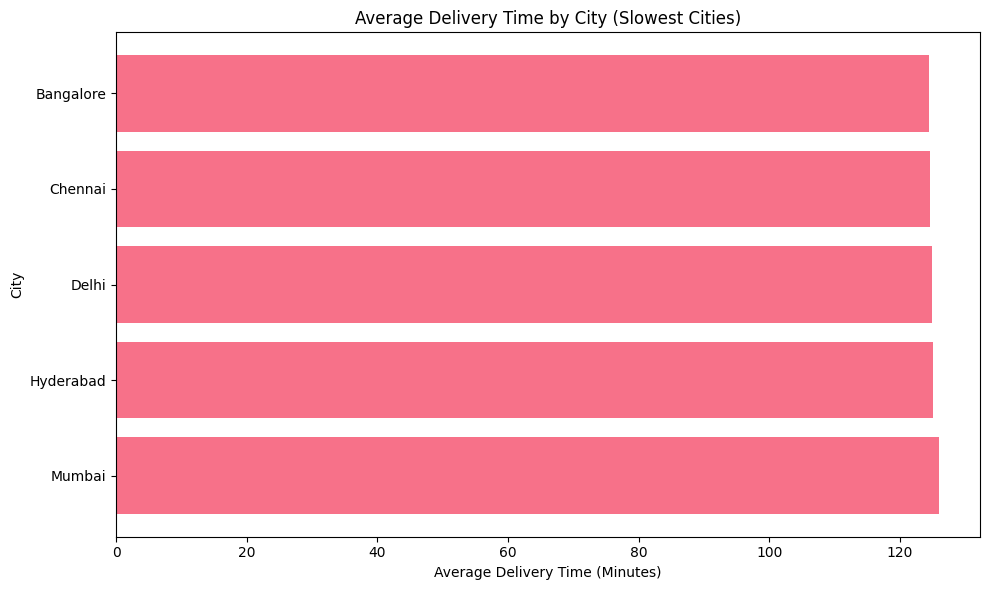

In [18]:
# Visualize delivery time by city
plt.figure(figsize=(10, 6))
plt.barh(range(len(city_delivery)), city_delivery['Delivery_Time_Min'])
plt.yticks(range(len(city_delivery)), city_delivery['City'])
plt.xlabel('Average Delivery Time (Minutes)')
plt.ylabel('City')
plt.title('Average Delivery Time by City (Slowest Cities)')
plt.tight_layout()
plt.show()

- **Observation:** Average delivery times remain consistently high across major cities, with Mumbai showing the highest delivery duration among the listed locations.  

- **Possible Reason:** Increased traffic congestion, high order volumes, longer delivery distances, or operational inefficiencies may be contributing to delayed deliveries.  

- **Business Recommendation:** Optimize delivery routes, increase delivery partner availability during peak hours, and establish additional delivery hubs to reduce delivery time and improve customer satisfaction.


## Analysis 8: Distance vs Delivery Time Relationship

**Business Question**: Does longer distance always mean longer delivery time?

**Why important**: Understanding this relationship helps optimize delivery routing.

In [19]:
# Calculate correlation between distance and delivery time
correlation = df['Distance_km'].corr(df['Delivery_Time_Min'])

print(f"Correlation between Distance and Delivery Time: {correlation:.3f}")
print("\n")
print("Interpretation:")
if correlation > 0.7:
    print("Strong positive correlation - Longer distance = Longer delivery time")
elif correlation > 0.4:
    print("Moderate positive correlation - Distance affects delivery time, but other factors also matter")
else:
    print("Weak correlation - Other factors like traffic, route optimization matter more")
print("\n")

Correlation between Distance and Delivery Time: 0.002


Interpretation:
Weak correlation - Other factors like traffic, route optimization matter more




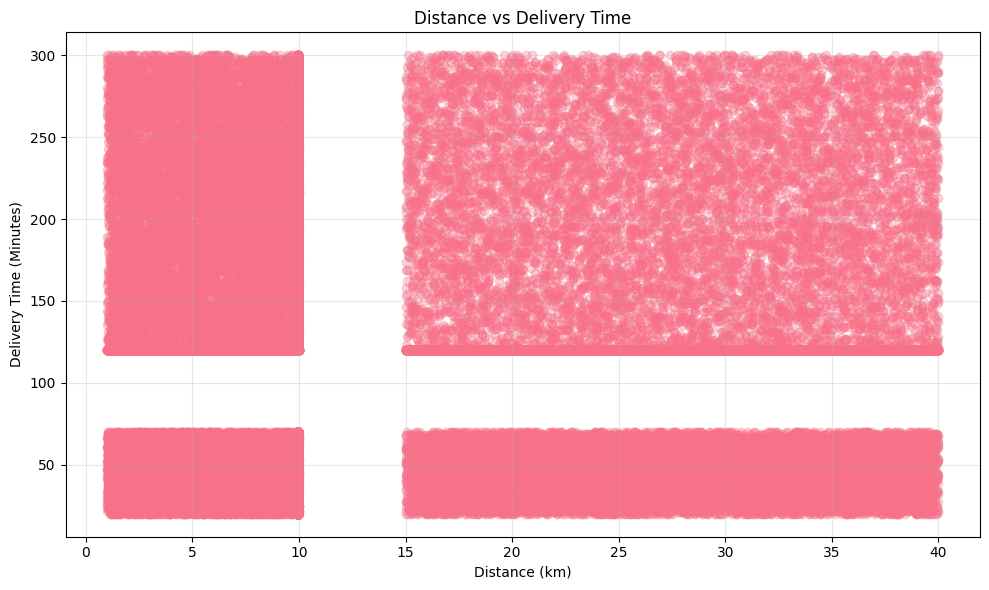

In [20]:
# Visualize distance vs delivery time
plt.figure(figsize=(10, 6))
plt.scatter(df['Distance_km'], df['Delivery_Time_Min'], alpha=0.3)
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (Minutes)')
plt.title('Distance vs Delivery Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- **Observation:** Delivery time generally increases as delivery distance increases, with several orders showing extremely high delivery times across different distance ranges.  

- **Possible Reason:** Traffic congestion, inefficient route allocation, peak-hour demand, or operational delays may be causing inconsistent delivery performance and outlier delivery times.  

- **Business Recommendation:** Implement route optimization, real-time delivery tracking, and dynamic delivery partner allocation to reduce delays and improve delivery efficiency.


## Analysis 9: Delivery Rating vs Delivery Time

**Business Question**: Do faster deliveries get better ratings?

**Why important**: Confirms if investing in faster delivery will improve customer satisfaction.

In [21]:
# Create delivery time bins
df['Delivery_Time_Group'] = pd.cut(df['Delivery_Time_Min'],
                                     bins=[0, 30, 60, 90, 120, 300],
                                     labels=['0-30 min', '31-60 min', '61-90 min', '91-120 min', '120+ min'])

# Calculate average rating by delivery time group
time_rating = df.groupby('Delivery_Time_Group')['Delivery_Rating'].mean().reset_index()

print("Average Delivery Rating by Delivery Time:")
print("\n")
print(time_rating)
print("\n")

Average Delivery Rating by Delivery Time:


  Delivery_Time_Group  Delivery_Rating
0            0-30 min         2.260810
1           31-60 min         2.263343
2           61-90 min         2.243481
3          91-120 min         2.263258
4            120+ min         2.264603




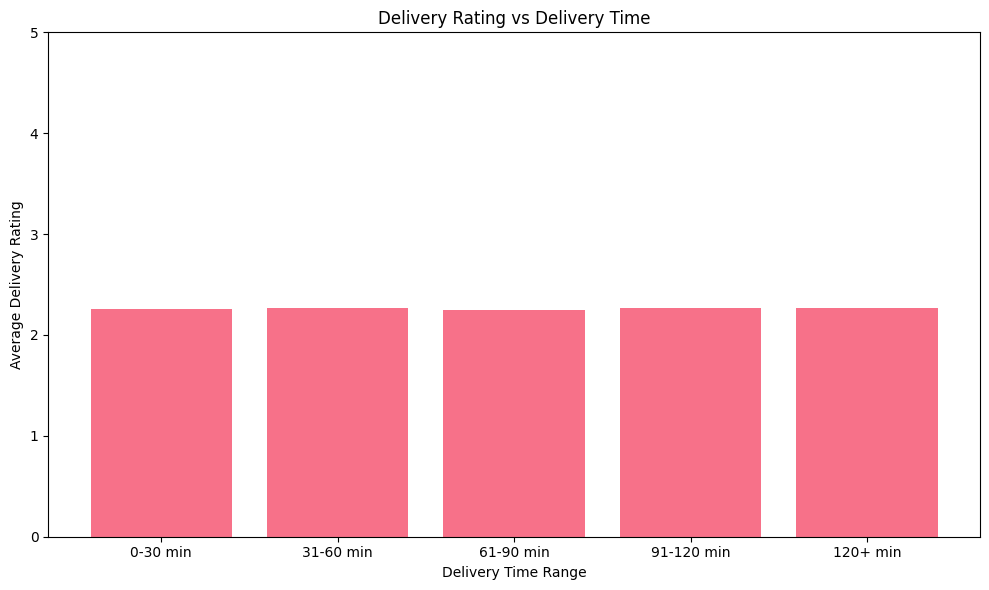

In [22]:
# Visualize rating vs delivery time
plt.figure(figsize=(10, 6))
plt.bar(time_rating['Delivery_Time_Group'], time_rating['Delivery_Rating'])
plt.xlabel('Delivery Time Range')
plt.ylabel('Average Delivery Rating')
plt.title('Delivery Rating vs Delivery Time')
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

- **Observation:** Delivery ratings remain consistently low across all delivery time ranges, showing minimal variation even for faster deliveries.  

- **Possible Reason:** Customer dissatisfaction may be influenced not only by delivery time but also by food quality, packaging issues, service experience, or inaccurate expectations.  

- **Business Recommendation:** Improve overall customer experience by focusing on delivery quality, packaging standards, order accuracy, and customer support alongside reducing delivery delays.

---
# Part 4: Restaurant Performance Analysis
---

## Analysis 10: Top-Rated Restaurants

**Business Question**: Which restaurants have the best ratings?

**Why important**: Top-rated restaurants should be featured prominently to attract more customers.

In [23]:
# Calculate average rating and order count per restaurant
restaurant_performance = df.groupby('Restaurant_Name').agg({
    'Restaurant_Rating': 'mean',
    'Order_ID': 'count'
}).reset_index()

restaurant_performance.columns = ['Restaurant_Name', 'Avg_Rating', 'Order_Count']

# Filter restaurants with at least 10 orders (for reliable ratings)
restaurant_performance = restaurant_performance[restaurant_performance['Order_Count'] >= 10]

# Sort by rating
top_restaurants = restaurant_performance.sort_values('Avg_Rating', ascending=False).head(10)

print("Top 10 Rated Restaurants (with at least 10 orders):")
print("\n")
print(top_restaurants)
print("\n")

Top 10 Rated Restaurants (with at least 10 orders):


    Restaurant_Name  Avg_Rating  Order_Count
3    Restaurant_101    4.325843          178
0      Restaurant_1    4.313472          193
70   Restaurant_162    4.308242          182
440  Restaurant_496    4.304433          203
284  Restaurant_355    4.301657          181
424  Restaurant_481    4.300526          190
122  Restaurant_209    4.300000          212
7    Restaurant_105    4.292019          213
243  Restaurant_318    4.292000          175
325  Restaurant_392    4.291257          183




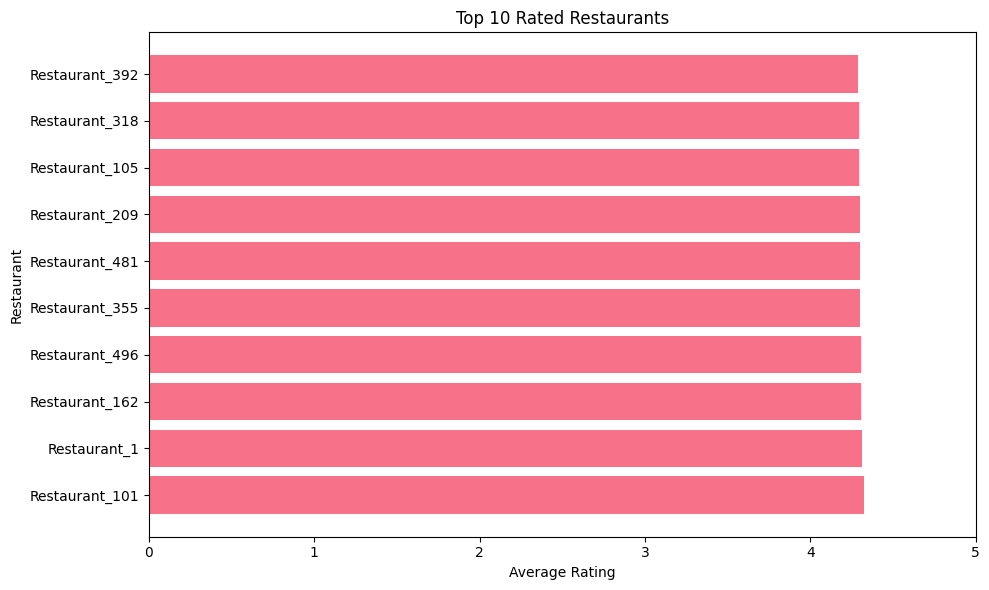

In [24]:
# Visualize top restaurants
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_restaurants)), top_restaurants['Avg_Rating'])
plt.yticks(range(len(top_restaurants)), top_restaurants['Restaurant_Name'])
plt.xlabel('Average Rating')
plt.ylabel('Restaurant')
plt.title('Top 10 Rated Restaurants')
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

- **Observation:** The top-rated restaurants maintain consistently high customer ratings, indicating strong service and food quality performance.  

- **Possible Reason:** High ratings may be driven by better food quality, faster delivery experience, consistent customer service, and positive customer satisfaction levels.  

- **Business Recommendation:** Identify the best practices followed by top-performing restaurants and apply similar quality standards, service improvements, and operational strategies across lower-rated restaurants.

## Analysis 11: Cancellation Rate by Restaurant

**Business Question**: Which restaurants have high cancellation rates?

**Why important**: High cancellation rates indicate problems that need to be addressed.

In [25]:
# Calculate cancellation rate per restaurant
restaurant_cancellation = df.groupby('Restaurant_Name').agg({
    'Order_ID': 'count',
    'Order_Status': lambda x: (x == 'Cancelled').sum()
}).reset_index()

restaurant_cancellation.columns = ['Restaurant_Name', 'Total_Orders', 'Cancelled_Orders']

# Calculate cancellation rate
restaurant_cancellation['Cancellation_Rate'] = (restaurant_cancellation['Cancelled_Orders'] / restaurant_cancellation['Total_Orders']) * 100

# Filter restaurants with at least 10 orders
restaurant_cancellation = restaurant_cancellation[restaurant_cancellation['Total_Orders'] >= 10]

# Get top 10 with highest cancellation
high_cancellation = restaurant_cancellation.sort_values('Cancellation_Rate', ascending=False).head(10)

print("Top 10 Restaurants with Highest Cancellation Rates:")
print("\n")
print(high_cancellation)
print("\n")

Top 10 Restaurants with Highest Cancellation Rates:


    Restaurant_Name  Total_Orders  Cancelled_Orders  Cancellation_Rate
324  Restaurant_391           196                43          21.938776
323  Restaurant_390           201                44          21.890547
419  Restaurant_477           176                38          21.590909
115  Restaurant_202           204                44          21.568627
304  Restaurant_373           191                41          21.465969
363  Restaurant_426           212                45          21.226415
221  Restaurant_299           194                41          21.134021
395  Restaurant_455           180                38          21.111111
16   Restaurant_113           205                43          20.975610
148  Restaurant_232           177                37          20.903955




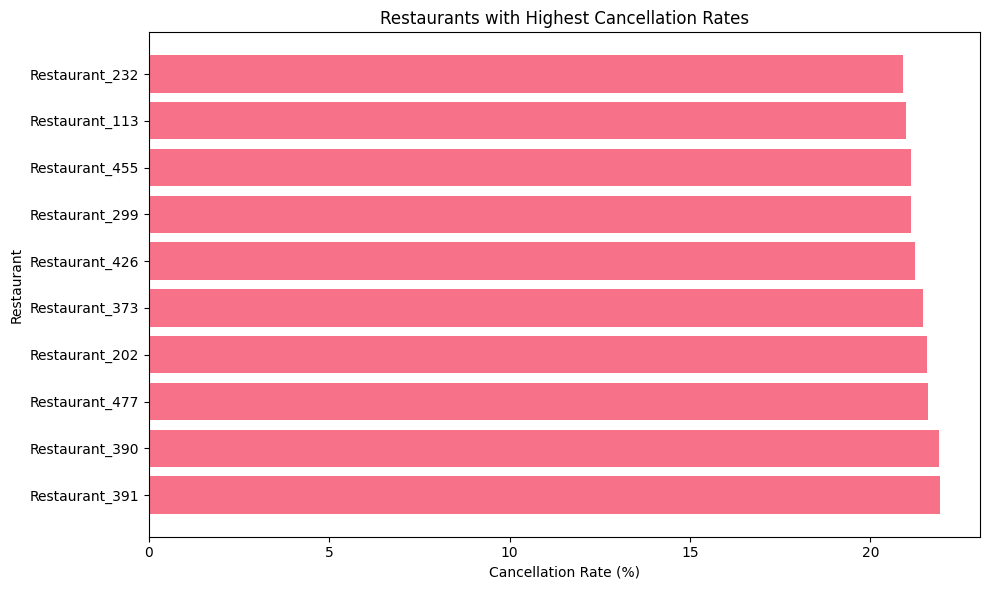

In [26]:
# Visualize cancellation rates
plt.figure(figsize=(10, 6))
plt.barh(range(len(high_cancellation)), high_cancellation['Cancellation_Rate'])
plt.yticks(range(len(high_cancellation)), high_cancellation['Restaurant_Name'])
plt.xlabel('Cancellation Rate (%)')
plt.ylabel('Restaurant')
plt.title('Restaurants with Highest Cancellation Rates')
plt.tight_layout()
plt.show()

- **Observation:** Certain restaurants show consistently high cancellation rates, indicating operational or service-related inefficiencies.  

- **Possible Reason:** High cancellations may be caused by delayed preparation, inventory shortages, long delivery times, or inaccurate order management.  

- **Business Recommendation:** Improve restaurant operational efficiency through better inventory tracking, order management systems, and delivery coordination to reduce cancellations and enhance customer satisfaction.

## Analysis 12: Cuisine-wise Performance

**Business Question**: How do different cuisines perform?

**Why important**: Helps decide which cuisines to focus on and which need improvement.

In [27]:
# Analyze cuisine performance
cuisine_performance = df.groupby('Cuisine_Type').agg({
    'Order_ID': 'count',
    'Final_Amount': 'sum',
    'Restaurant_Rating': 'mean',
    'Delivery_Rating': 'mean'
}).reset_index()

cuisine_performance.columns = ['Cuisine', 'Order_Count', 'Total_Revenue', 'Avg_Restaurant_Rating', 'Avg_Delivery_Rating']

# Sort by revenue
cuisine_performance = cuisine_performance.sort_values('Total_Revenue', ascending=False).head(10)

print("Top 10 Cuisines by Performance:")
print("\n")
print(cuisine_performance)
print("\n")

Top 10 Cuisines by Performance:


   Cuisine  Order_Count  Total_Revenue  Avg_Restaurant_Rating  \
2   Indian        20122   2.714629e+07               4.201178   
4  Mexican        20141   2.700087e+07               4.196246   
1  Chinese        19986   2.654096e+07               4.192134   
0  Arabian        20118   2.644586e+07               4.201849   
3  Italian        19633   2.583638e+07               4.207630   

   Avg_Delivery_Rating  
2             2.251565  
4             2.255548  
1             2.290003  
0             2.249627  
3             2.264707  




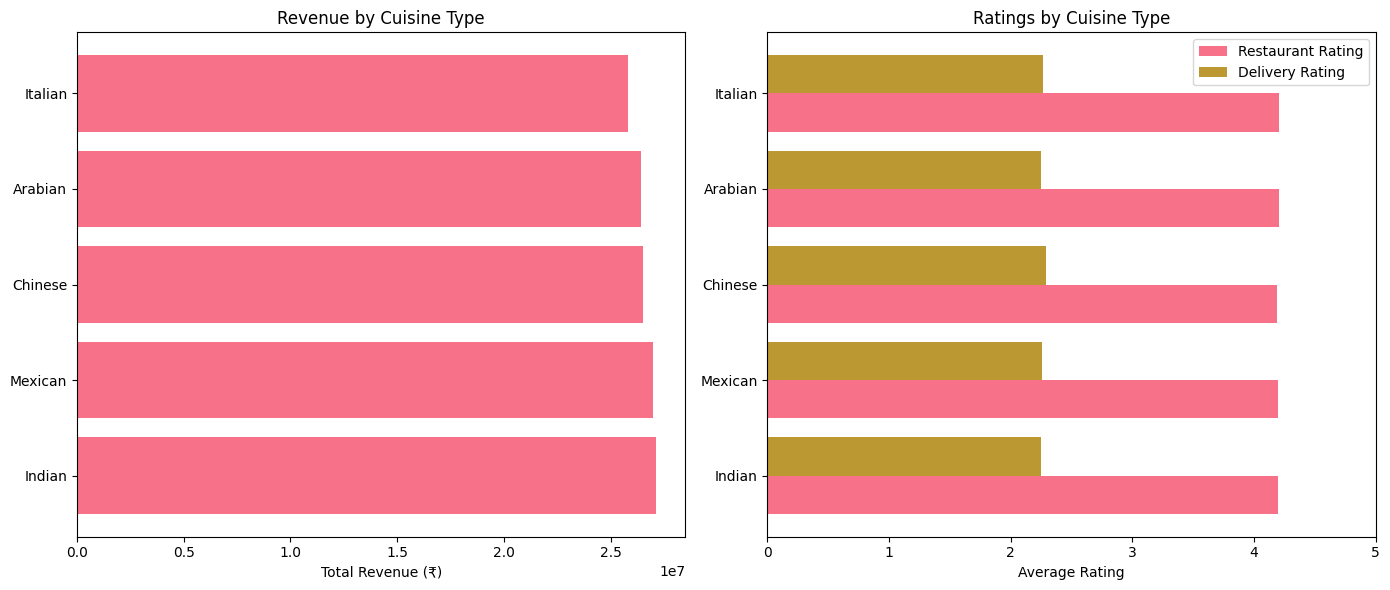

In [28]:
# Visualize cuisine performance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Revenue by cuisine
ax1.barh(range(len(cuisine_performance)), cuisine_performance['Total_Revenue'])
ax1.set_yticks(range(len(cuisine_performance)))
ax1.set_yticklabels(cuisine_performance['Cuisine'])
ax1.set_xlabel('Total Revenue (₹)')
ax1.set_title('Revenue by Cuisine Type')

# Plot 2: Average ratings by cuisine
x = range(len(cuisine_performance))
ax2.barh([i-0.2 for i in x], cuisine_performance['Avg_Restaurant_Rating'], height=0.4, label='Restaurant Rating')
ax2.barh([i+0.2 for i in x], cuisine_performance['Avg_Delivery_Rating'], height=0.4, label='Delivery Rating')
ax2.set_yticks(x)
ax2.set_yticklabels(cuisine_performance['Cuisine'])
ax2.set_xlabel('Average Rating')
ax2.set_title('Ratings by Cuisine Type')
ax2.legend()
ax2.set_xlim(0, 5)

plt.tight_layout()
plt.show()

- **Observation:** Indian cuisine generates the highest revenue, while restaurant ratings remain consistently high across all cuisine categories despite relatively lower delivery ratings.  

- **Possible Reason:** Strong customer preference and food quality may be driving revenue growth, whereas delivery experience and service efficiency may be reducing overall delivery ratings.  

- **Business Recommendation:** Maintain cuisine quality standards while improving delivery operations, packaging, and delivery partner performance to enhance overall customer satisfaction and retention.


---
# Part 5: Operational Insights
---

## Analysis 13: Peak Hour Demand Analysis

**Business Question**: When do we get the most orders?

**Why important**: Helps schedule delivery partners and prepare for high demand.

In [29]:
# Analyze peak hour patterns
peak_analysis = df.groupby('Peak_Hour').agg({
    'Order_ID': 'count',
    'Final_Amount': 'mean'
}).reset_index()

peak_analysis.columns = ['Is_Peak_Hour', 'Order_Count', 'Avg_Order_Value']

print("Peak Hour vs Non-Peak Hour:")
print("\n")
print(peak_analysis)
print("\n")

Peak Hour vs Non-Peak Hour:


   Is_Peak_Hour  Order_Count  Avg_Order_Value
0         False        33585      1853.806579
1          True        66415      1855.722329




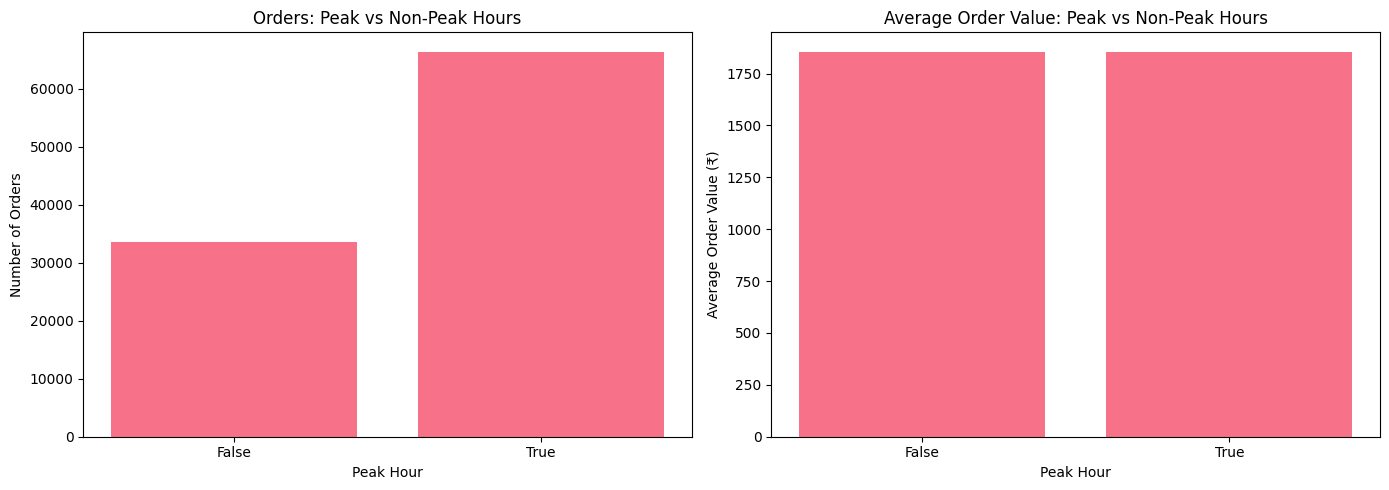

In [30]:
# Visualize peak hour demand
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Order count
ax1.bar(peak_analysis['Is_Peak_Hour'].astype(str), peak_analysis['Order_Count'])
ax1.set_xlabel('Peak Hour')
ax1.set_ylabel('Number of Orders')
ax1.set_title('Orders: Peak vs Non-Peak Hours')

# Plot 2: Average order value
ax2.bar(peak_analysis['Is_Peak_Hour'].astype(str), peak_analysis['Avg_Order_Value'])
ax2.set_xlabel('Peak Hour')
ax2.set_ylabel('Average Order Value (₹)')
ax2.set_title('Average Order Value: Peak vs Non-Peak Hours')

plt.tight_layout()
plt.show()

- **Observation:** Peak hours record significantly higher order volumes compared to non-peak hours, while the average order value remains nearly the same in both periods.  

- **Possible Reason:** Increased customer activity during lunch and dinner hours may be driving higher demand without affecting individual spending behavior.  

- **Business Recommendation:** Increase staffing, delivery partner availability, and operational efficiency during peak hours to manage demand effectively and reduce service delays.

## Analysis 14: Payment Mode Preferences

**Business Question**: How do customers prefer to pay?

**Why important**: Helps ensure we support the right payment methods.

In [31]:
# Analyze payment mode preferences
payment_analysis = df.groupby('Payment_Mode').agg({
    'Order_ID': 'count',
    'Final_Amount': 'sum'
}).reset_index()

payment_analysis.columns = ['Payment_Mode', 'Order_Count', 'Total_Revenue']

# Calculate percentages
payment_analysis['Order_Percentage'] = (payment_analysis['Order_Count'] / payment_analysis['Order_Count'].sum()) * 100

print("Payment Mode Analysis:")
print("\n")
print(payment_analysis)
print("\n")

Payment Mode Analysis:


  Payment_Mode  Order_Count  Total_Revenue  Order_Percentage
0          COD        19977   2.689530e+07            19.977
1         Card        20094   2.646112e+07            20.094
2          UPI        39843   5.299827e+07            39.843
3       Wallet        20086   2.661566e+07            20.086




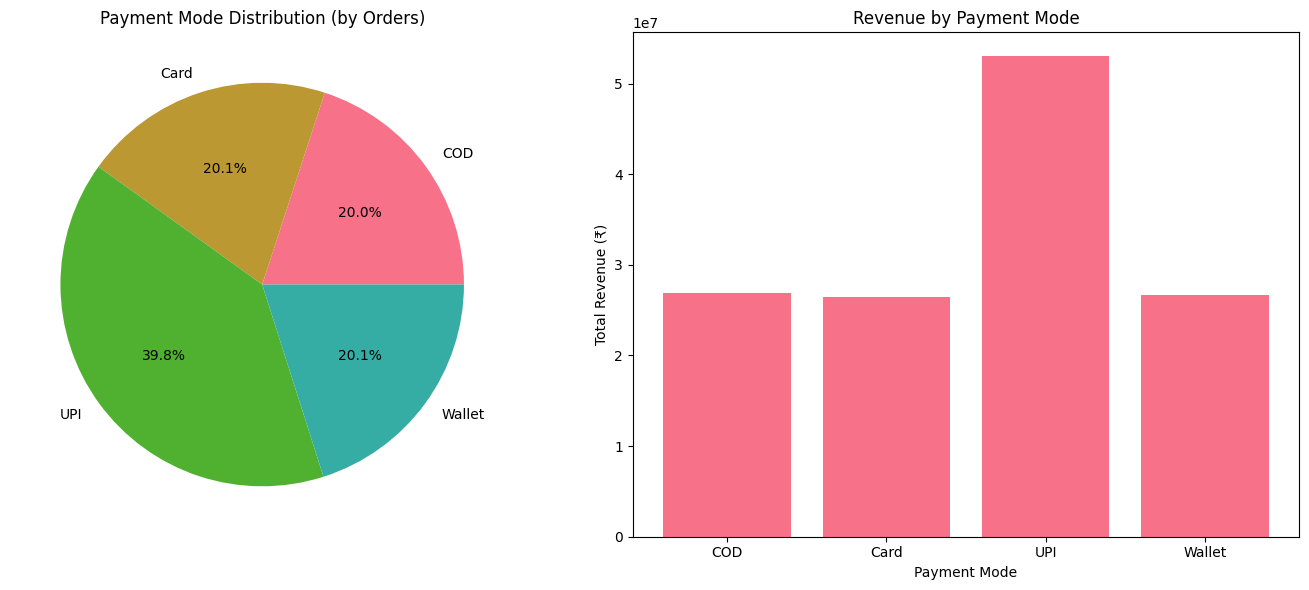

In [32]:
# Visualize payment preferences
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Pie chart of order count
ax1.pie(payment_analysis['Order_Count'], labels=payment_analysis['Payment_Mode'], autopct='%1.1f%%')
ax1.set_title('Payment Mode Distribution (by Orders)')

# Plot 2: Bar chart of revenue
ax2.bar(payment_analysis['Payment_Mode'], payment_analysis['Total_Revenue'])
ax2.set_xlabel('Payment Mode')
ax2.set_ylabel('Total Revenue (₹)')
ax2.set_title('Revenue by Payment Mode')

plt.tight_layout()
plt.show()

- **Observation:** UPI is the most preferred payment method, contributing the highest share of both total orders and overall revenue compared to other payment modes.  

- **Possible Reason:** Customers may prefer UPI due to faster transactions, convenience, cashback offers, and increasing adoption of digital payments.  

- **Business Recommendation:** Strengthen digital payment integrations, provide exclusive UPI-based offers, and optimize payment experience to improve transaction efficiency and customer retention.

## Analysis 15: Cancellation Reason Analysis

**Business Question**: Why do customers cancel orders?

**Why important**: Understanding cancellation reasons helps us fix problems and reduce cancellations.

In [33]:
# Filter cancelled orders
cancelled_orders = df[df['Order_Status'] == 'Cancelled']

# Analyze cancellation reasons
cancellation_reasons = cancelled_orders['Cancellation_Reason'].value_counts().reset_index()
cancellation_reasons.columns = ['Reason', 'Count']

# Calculate percentage
cancellation_reasons['Percentage'] = (cancellation_reasons['Count'] / cancellation_reasons['Count'].sum()) * 100

print("Cancellation Reasons:")
print("\n")
print(cancellation_reasons)
print("\n")

Cancellation Reasons:


               Reason  Count  Percentage
0             Unknown   6005   39.937483
1       Late Delivery   3059   20.344507
2  Customer Cancelled   2993   19.905560
3    Restaurant Issue   2979   19.812450




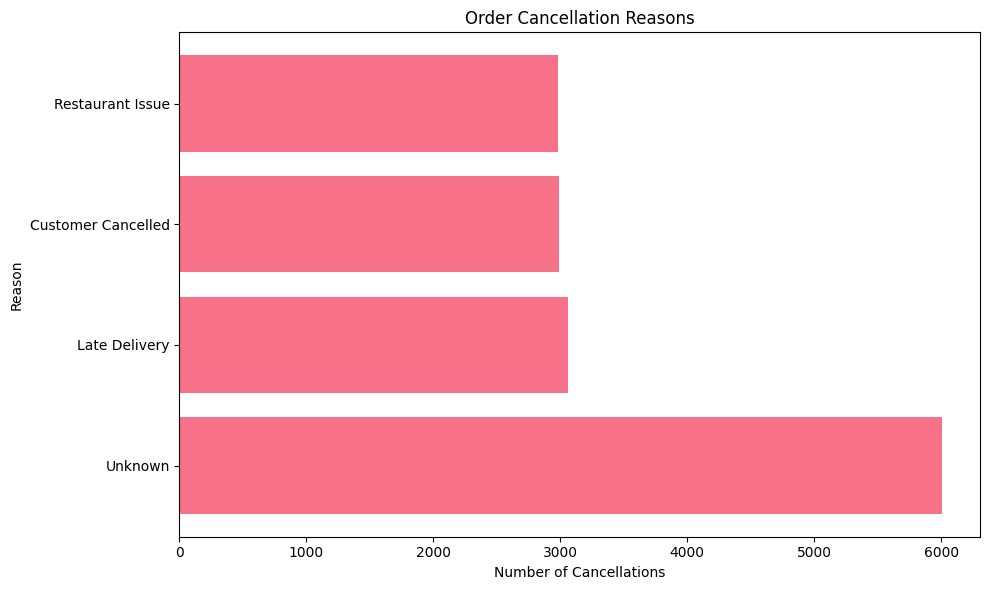

In [34]:
# Visualize cancellation reasons
plt.figure(figsize=(10, 6))
plt.barh(range(len(cancellation_reasons)), cancellation_reasons['Count'])
plt.yticks(range(len(cancellation_reasons)), cancellation_reasons['Reason'])
plt.xlabel('Number of Cancellations')
plt.ylabel('Reason')
plt.title('Order Cancellation Reasons')
plt.tight_layout()
plt.show()


- **Observation:** A large portion of order cancellations falls under the "Unknown" category, while late delivery, restaurant issues, and customer cancellations contribute comparatively lower but similar counts.  

- **Possible Reason:** Missing or incomplete cancellation tracking processes may be causing poor visibility into the actual reasons behind order cancellations.  

- **Business Recommendation:** Improve cancellation reason tracking and data collection systems to identify operational issues accurately and implement targeted strategies to reduce cancellations.